In [1]:
# =========================================
# IMPORT LIBRARIES
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR

import warnings
warnings.filterwarnings("ignore")

# =========================================
# LOAD DATASET
# =========================================

df = pd.read_csv("youtube_ad_revenue_dataset.csv")

print(df.head())
print(df.shape)
print(df.info())
print(df.describe())


   video_id                        date  views   likes  comments  \
0  vid_3092  2024-09-24 10:50:40.993199   9936  1221.0     320.0   
1  vid_3459  2024-09-22 10:50:40.993199  10017   642.0     346.0   
2  vid_4784  2024-11-21 10:50:40.993199  10097  1979.0     187.0   
3  vid_4078  2025-01-28 10:50:40.993199  10034  1191.0     242.0   
4  vid_3522  2025-04-28 10:50:40.993199   9889  1858.0     477.0   

   watch_time_minutes  video_length_minutes  subscribers       category  \
0        26497.214184              2.862137       228086  Entertainment   
1        15209.747445             23.738069       736015         Gaming   
2        57332.658498             26.200634       240534      Education   
3        31334.517771             11.770340       434482  Entertainment   
4        15665.666434              6.635854        42030      Education   

   device country  ad_revenue_usd  
0      TV      IN      203.178237  
1  Tablet      CA      140.880508  
2      TV      CA      360.13400

In [2]:
!pip install seaborn scikit-learn matplotlib pandas numpy


'pip' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
import seaborn as sns

In [4]:
import sys
!{sys.executable} -m pip install seaborn scikit-learn matplotlib pandas numpy


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: C:\Users\ELCOT\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [5]:
import seaborn as sns

In [6]:
python.exe -m pip install --upgrade pip

SyntaxError: invalid syntax (842801469.py, line 1)

In [7]:
C:\Users\ELCOT\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip

SyntaxError: unexpected character after line continuation character (4136603892.py, line 1)

In [8]:
import sys
!{sys.executable} -m pip install seaborn scikit-learn matplotlib pandas numpy


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: C:\Users\ELCOT\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [9]:
import seaborn as sns

In [10]:
# =========================================
# CHECK MISSING VALUES
# =========================================

print("Missing Values:")
print(df.isnull().sum())

# =========================================
# FILL MISSING VALUES
# =========================================

num_cols = ['likes', 'comments', 'watch_time_minutes']

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

print("\nAfter Filling Missing Values:")
print(df.isnull().sum())

# =========================================
# REMOVE DUPLICATES
# =========================================

print("\nBefore Duplicate Removal:", df.shape)

df.drop_duplicates(inplace=True)

print("After Duplicate Removal:", df.shape)

# =========================================
# FEATURE ENGINEERING
# =========================================

# Engagement Rate Feature

df['engagement_rate'] = (df['likes'] + df['comments']) / df['views']

# Convert date column to datetime

df['date'] = pd.to_datetime(df['date'])

# Extract Month and Day

df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

print("\nUpdated Data:")
print(df.head())


Missing Values:
video_id                   0
date                       0
views                      0
likes                   6117
comments                6112
watch_time_minutes      6105
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
ad_revenue_usd             0
dtype: int64

After Filling Missing Values:
video_id                   0
date                       0
views                      0
likes                   6117
comments                6112
watch_time_minutes      6105
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
ad_revenue_usd             0
dtype: int64

Before Duplicate Removal: (122400, 12)
After Duplicate Removal: (120000, 12)

Updated Data:
   video_id                       date  views   likes  comments  \
0  vid_3092 2024-09-24 10:50:40.993199   9936  1221.0     320.0   
1  v

In [11]:
# =========================================
# LABEL ENCODING
# =========================================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = ['video_id', 'category', 'device', 'country']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Drop original date column

df.drop('date', axis=1, inplace=True)

print("Encoded Dataset:")
print(df.head())


Encoded Dataset:
   video_id  views   likes  comments  watch_time_minutes  \
0      2326   9936  1221.0     320.0        26497.214184   
1      2733  10017   642.0     346.0        15209.747445   
2      4205  10097  1979.0     187.0        57332.658498   
3      3421  10034  1191.0     242.0        31334.517771   
4      2804   9889  1858.0     477.0        15665.666434   

   video_length_minutes  subscribers  category  device  country  \
0              2.862137       228086         1       2        3   
1             23.738069       736015         2       3        1   
2             26.200634       240534         0       2        1   
3             11.770340       434482         1       1        4   
4              6.635854        42030         0       1        1   

   ad_revenue_usd  engagement_rate  month  day  
0      203.178237         0.155093      9   24  
1      140.880508         0.098632      9   22  
2      360.134008         0.214519     11   21  
3      224.638261      

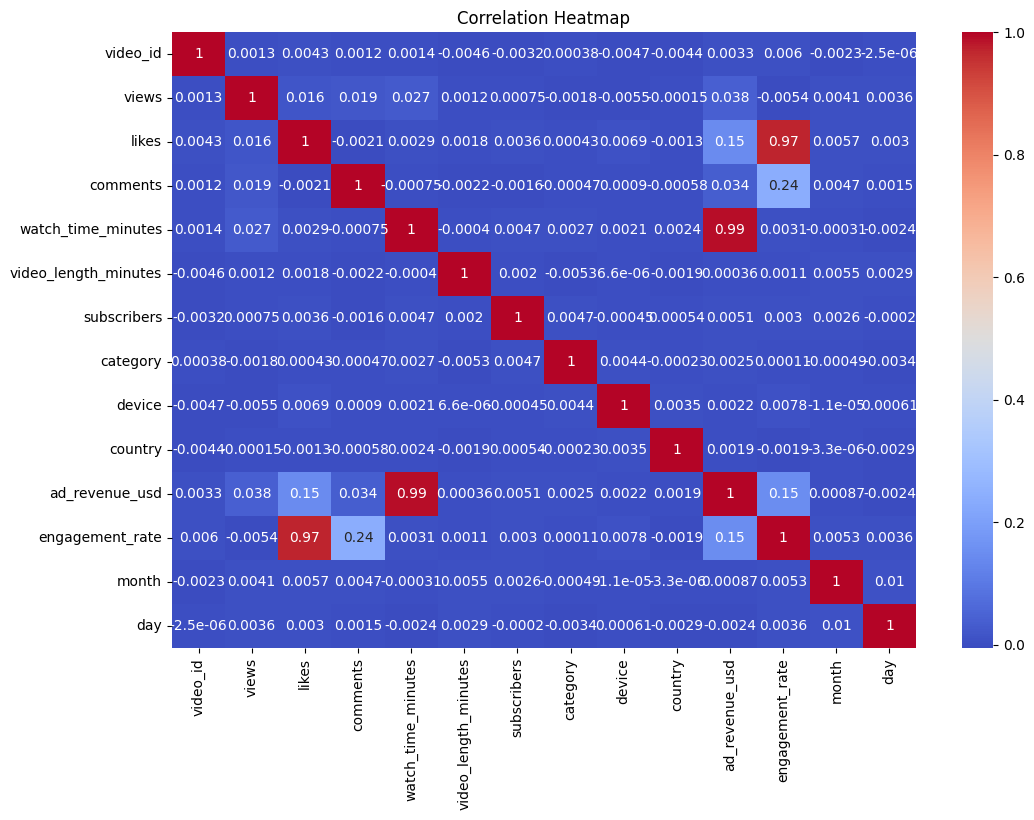

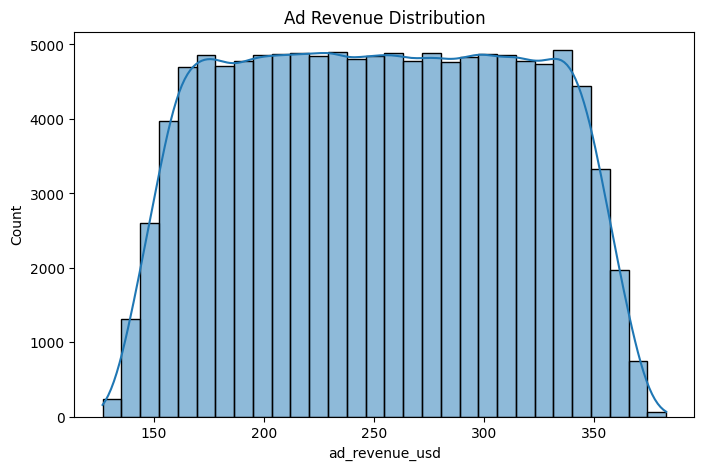

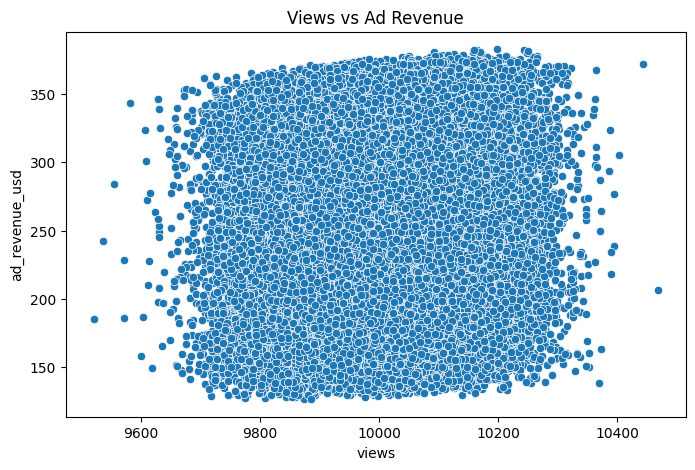

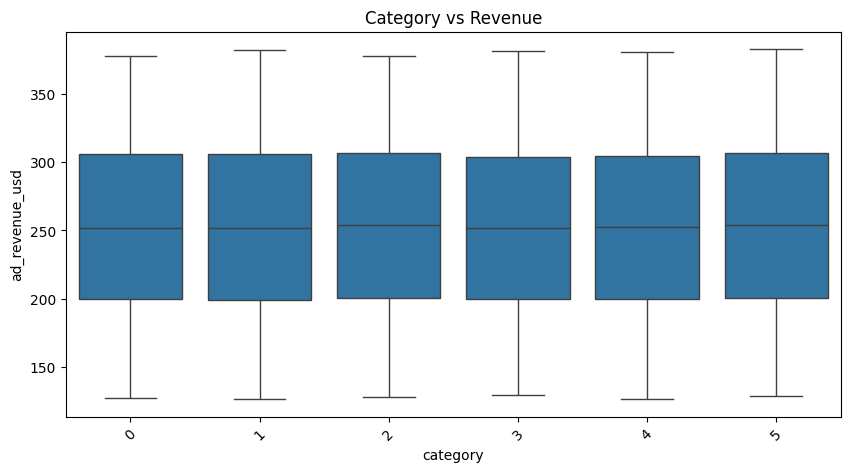

In [12]:
# =========================================
# EDA VISUALIZATIONS
# =========================================

import seaborn as sns
import matplotlib.pyplot as plt

# Correlation Heatmap

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Revenue Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['ad_revenue_usd'], bins=30, kde=True)
plt.title("Ad Revenue Distribution")
plt.show()

# Views vs Revenue

plt.figure(figsize=(8,5))
sns.scatterplot(x=df['views'], y=df['ad_revenue_usd'])
plt.title("Views vs Ad Revenue")
plt.show()

# Category vs Revenue

plt.figure(figsize=(10,5))
sns.boxplot(x=df['category'], y=df['ad_revenue_usd'])
plt.title("Category vs Revenue")
plt.xticks(rotation=45)
plt.show()


In [14]:
# =========================================
# FEATURES AND TARGET
# =========================================

X = df.drop("ad_revenue_usd", axis=1)
y = df["ad_revenue_usd"]

# =========================================
# TRAIN TEST SPLIT
# =========================================# =========================================
# MODEL BUILDING
# =========================================

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "Support Vector Regressor": SVR()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append([name, r2, mae, rmse])

results_df = pd.DataFrame(
    results,
    columns=["Model", "R2 Score", "MAE", "RMSE"]
)

print(results_df)


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

# =========================================
# FEATURE SCALING
# =========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [15]:
# =========================================
# REMOVE ALL REMAINING NaN VALUES
# =========================================

print("Missing values before fixing:")
print(df.isnull().sum())

# Fill all numeric columns with median

numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_columns:
    df[col].fillna(df[col].median(), inplace=True)

# Final check

print("\nMissing values after fixing:")
print(df.isnull().sum())


Missing values before fixing:
video_id                    0
views                       0
likes                    6000
comments                 6000
watch_time_minutes       6000
video_length_minutes        0
subscribers                 0
category                    0
device                      0
country                     0
ad_revenue_usd              0
engagement_rate         11696
month                       0
day                         0
dtype: int64

Missing values after fixing:
video_id                    0
views                       0
likes                    6000
comments                 6000
watch_time_minutes       6000
video_length_minutes        0
subscribers                 0
category                    0
device                      0
country                     0
ad_revenue_usd              0
engagement_rate         11696
month                       0
day                         0
dtype: int64


In [16]:
# =========================================
# MODEL BUILDING
# =========================================

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "Support Vector Regressor": SVR()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append([name, r2, mae, rmse])

results_df = pd.DataFrame(
    results,
    columns=["Model", "R2 Score", "MAE", "RMSE"]
)

print(results_df)


ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [17]:
# =========================================
# BEST MODEL SELECTION
# =========================================

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

print("Final Model Comparison:")
print(results_df)


NameError: name 'results_df' is not defined

In [18]:
# =========================================
# FINAL CLEANING BEFORE MODEL
# =========================================

# Fill all numeric missing values

numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Replace any infinity values if present

df.replace([np.inf, -np.inf], np.nan, inplace=True)

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Safe fix for engagement rate

df['engagement_rate'] = df['engagement_rate'].fillna(0)

print("Final Missing Values Check:")
print(df.isnull().sum())


Final Missing Values Check:
video_id                0
views                   0
likes                   0
comments                0
watch_time_minutes      0
video_length_minutes    0
subscribers             0
category                0
device                  0
country                 0
ad_revenue_usd          0
engagement_rate         0
month                   0
day                     0
dtype: int64


In [ ]:
# =========================================
# FEATURES AND TARGET
# =========================================

X = df.drop("ad_revenue_usd", axis=1)
y = df["ad_revenue_usd"]

# =========================================
# TRAIN TEST SPLIT
# =========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================================
# FEATURE SCALING
# =========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================================
# MODEL BUILDING
# =========================================

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "Support Vector Regressor": SVR()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append([name, r2, mae, rmse])

results_df = pd.DataFrame(
    results,
    columns=["Model", "R2 Score", "MAE", "RMSE"]
)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

print(results_df)


In [ ]:
# =========================================
# FIX ALL NaN + Infinity VALUES
# =========================================

# Safe engagement rate calculation

df['engagement_rate'] = np.where(
    df['views'] == 0,
    0,
    (df['likes'] + df['comments']) / df['views']
)

# Replace infinity values

df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill ALL missing values in numeric columns

numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Final check

print("Final Missing Values Check:")
print(df.isnull().sum())


In [ ]:
# =========================================
# FEATURES AND TARGET
# =========================================

X = df.drop("ad_revenue_usd", axis=1)
y = df["ad_revenue_usd"]

# Extra safety check

print(X.isnull().sum())

# Remove any remaining rows with NaN

X = X.dropna()
y = y.loc[X.index]

# =========================================
# TRAIN TEST SPLIT
# =========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# =========================================
# SCALING
# =========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================================
# LINEAR REGRESSION TEST FIRST
# =========================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))


In [ ]:
# =========================================
# LINEAR REGRESSION TEST FIRST
# =========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Features and Target

X = df.drop("ad_revenue_usd", axis=1)
y = df["ad_revenue_usd"]

# Extra safety check

print("Missing values in X:")
print(X.isnull().sum())

# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Linear Regression Model

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# R2 Score

print("R2 Score:", r2_score(y_test, y_pred))


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Use small sample for faster testing

sample_df = df.sample(10000, random_state=42)

X = sample_df.drop("ad_revenue_usd", axis=1)
y = sample_df["ad_revenue_usd"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))


In [ ]:
print(df.shape)
print(df.head())


In [ ]:
print(df.shape)
print(df.head())

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Use small sample for faster testing

sample_df = df.sample(10000, random_state=42)

X = sample_df.drop("ad_revenue_usd", axis=1)
y = sample_df["ad_revenue_usd"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))


In [ ]:
import pandas as pd

df = pd.read_csv("youtube_ad_revenue_dataset.csv")

print(df.shape)
print(df.head())


In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Label Encoding

le = LabelEncoder()

cat_cols = ['video_id', 'category', 'device', 'country']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Feature Engineering

df['date'] = pd.to_datetime(df['date'])

df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

df.drop('date', axis=1, inplace=True)

# Safe engagement rate

df['engagement_rate'] = np.where(
    df['views'] == 0,
    0,
    (df['likes'] + df['comments']) / df['views']
)

# Fill missing values

numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

sample_df = df.sample(10000, random_state=42)

X = sample_df.drop("ad_revenue_usd", axis=1)
y = sample_df["ad_revenue_usd"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))


In [2]:
print(df.shape)
print(df.head())

NameError: name 'df' is not defined

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Use small sample for faster testing

sample_df = df.sample(10000, random_state=42)

X = sample_df.drop("ad_revenue_usd", axis=1)
y = sample_df["ad_revenue_usd"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))


In [1]:
import pandas as pd

df = pd.read_csv("youtube_ad_revenue_dataset.csv")

print(df.shape)
print(df.head())


(122400, 12)
   video_id                        date  views   likes  comments  \
0  vid_3092  2024-09-24 10:50:40.993199   9936  1221.0     320.0   
1  vid_3459  2024-09-22 10:50:40.993199  10017   642.0     346.0   
2  vid_4784  2024-11-21 10:50:40.993199  10097  1979.0     187.0   
3  vid_4078  2025-01-28 10:50:40.993199  10034  1191.0     242.0   
4  vid_3522  2025-04-28 10:50:40.993199   9889  1858.0     477.0   

   watch_time_minutes  video_length_minutes  subscribers       category  \
0        26497.214184              2.862137       228086  Entertainment   
1        15209.747445             23.738069       736015         Gaming   
2        57332.658498             26.200634       240534      Education   
3        31334.517771             11.770340       434482  Entertainment   
4        15665.666434              6.635854        42030      Education   

   device country  ad_revenue_usd  
0      TV      IN      203.178237  
1  Tablet      CA      140.880508  
2      TV      CA  

In [2]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Label Encoding

le = LabelEncoder()

cat_cols = ['video_id', 'category', 'device', 'country']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Feature Engineering

df['date'] = pd.to_datetime(df['date'])

df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

df.drop('date', axis=1, inplace=True)

# Safe engagement rate

df['engagement_rate'] = np.where(
    df['views'] == 0,
    0,
    (df['likes'] + df['comments']) / df['views']
)

# Fill missing values

numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())


video_id                0
views                   0
likes                   0
comments                0
watch_time_minutes      0
video_length_minutes    0
subscribers             0
category                0
device                  0
country                 0
ad_revenue_usd          0
month                   0
day                     0
engagement_rate         0
dtype: int64


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

sample_df = df.sample(10000, random_state=42)

X = sample_df.drop("ad_revenue_usd", axis=1)
y = sample_df["ad_revenue_usd"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))


R2 Score: 0.9438103946607392


In [4]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "Support Vector Regressor": SVR()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append([name, r2, mae, rmse])

results_df = pd.DataFrame(
    results,
    columns=["Model", "R2 Score", "MAE", "RMSE"]
)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

print(results_df)


                      Model  R2 Score        MAE       RMSE
0         Linear Regression  0.943810   3.645646  14.465243
3         Gradient Boosting  0.940765   4.614103  14.852045
2             Random Forest  0.939542   4.475512  15.004601
1             Decision Tree  0.881106   6.894219  21.041581
4  Support Vector Regressor  0.140731  48.806152  56.566899
